In [7]:
import numpy as np
import torch
import torchvision.datasets as datasets 
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import os

In [8]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Load the MNIST dataset
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# Create a dataloader for the training
train_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=10, shuffle=True)

# Load the MNIST test set
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(mnist_testset, batch_size=10, shuffle=True)

# Define the device
device = "cpu"

In [9]:
class NeuralNET(nn.Module):
    def __init__(self, hidden_size_1=32, hidden_size_2=16):
        super(NeuralNET,self).__init__()
        self.linear1 = nn.Linear(28*28, hidden_size_1) 
        self.linear2 = nn.Linear(hidden_size_1, hidden_size_2) 
        self.linear3 = nn.Linear(hidden_size_2, 10)
        self.relu = nn.ReLU()

    def forward(self, img):
        x = img.view(-1, 28*28)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        return x

In [10]:
net = NeuralNET().to(device)

In [11]:
def train(train_loader, net, epochs=5, total_iterations_limit=None):
    cross_el = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

    total_iterations = 0

    for epoch in range(epochs):
        net.train()

        loss_sum = 0
        num_iterations = 0

        data_iterator = tqdm(train_loader, desc=f'Epoch {epoch+1}')
        if total_iterations_limit is not None:
            data_iterator.total = total_iterations_limit
        for data in data_iterator:
            num_iterations += 1
            total_iterations += 1
            x, y = data
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            output = net(x.view(-1, 28*28))
            loss = cross_el(output, y)
            loss_sum += loss.item()
            avg_loss = loss_sum / num_iterations
            data_iterator.set_postfix(loss=avg_loss)
            loss.backward()
            optimizer.step()

            if total_iterations_limit is not None and total_iterations >= total_iterations_limit:
                return
            
def print_size_of_model(model):
    torch.save(model.state_dict(), "temp_delme.p")
    print('Size (KB):', os.path.getsize("temp_delme.p")/1e3)
    os.remove('temp_delme.p')

MODEL_FILENAME = 'NeuralNET_ptq.pt'

if Path(MODEL_FILENAME).exists():
    net.load_state_dict(torch.load(MODEL_FILENAME))
    print('Loaded model from disk')
else:
    train(train_loader, net, epochs=5)
    # Save the model to disk
    torch.save(net.state_dict(), MODEL_FILENAME)

Epoch 1:   0%|          | 0/6000 [00:00<?, ?it/s]

Epoch 5: 100%|██████████| 6000/6000 [00:21<00:00, 274.47it/s, loss=0.0985]


In [12]:
def test(model: nn.Module, total_iterations: int = None):
    correct = 0
    total = 0

    iterations = 0

    model.eval()

    with torch.no_grad():
        for data in tqdm(test_loader, desc='Testing'):
            x, y = data
            x = x.to(device)
            y = y.to(device)
            output = model(x.view(-1, 784))
            for idx, i in enumerate(output):
                if torch.argmax(i) == y[idx]:
                    correct +=1
                total +=1
            iterations += 1
            if total_iterations is not None and iterations >= total_iterations:
                break
    print(f'Accuracy: {round(correct/total, 3)}')

In [13]:
# Print the weights matrix of the model before quantization
print('Weights before quantization')
print(net.linear1.weight)
print(net.linear1.weight.dtype)

Weights before quantization
Parameter containing:
tensor([[-0.0179, -0.0013,  0.0171,  ...,  0.0325,  0.0044, -0.0293],
        [-0.0281, -0.0010, -0.0037,  ..., -0.0166,  0.0340,  0.0239],
        [ 0.0300,  0.0048,  0.0095,  ...,  0.0075,  0.0363,  0.0161],
        ...,
        [-0.0177, -0.0036, -0.0191,  ...,  0.0044,  0.0124,  0.0078],
        [ 0.0144,  0.0520,  0.0559,  ..., -0.0001,  0.0175,  0.0048],
        [ 0.0521,  0.0725,  0.0220,  ...,  0.0724,  0.0581,  0.0017]],
       requires_grad=True)
torch.float32


In [14]:
print('Size of the model before quantization')
print_size_of_model(net)

Size of the model before quantization
Size (KB): 106.297


In [15]:
print(f'Accuracy of the model before quantization: ')
test(net)

Accuracy of the model before quantization: 


Testing: 100%|██████████| 1000/1000 [00:02<00:00, 459.22it/s]

Accuracy: 0.966


In [16]:
class QuantizedNuralNet(nn.Module):
    def __init__(self, hidden_size_1=32, hidden_size_2=16):
        super(QuantizedNuralNet,self).__init__()
        self.quant = torch.quantization.QuantStub()
        self.linear1 = nn.Linear(28*28, hidden_size_1) 
        self.linear2 = nn.Linear(hidden_size_1, hidden_size_2) 
        self.linear3 = nn.Linear(hidden_size_2, 10)
        self.relu = nn.ReLU()
        self.dequant = torch.quantization.DeQuantStub()

    def forward(self, img):
        x = img.view(-1, 28*28)
        x = self.quant(x)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        x = self.dequant(x)
        return x

In [17]:
net_quantized = QuantizedNuralNet().to(device)
# Copy weights from unquantized model
net_quantized.load_state_dict(net.state_dict())
net_quantized.eval()

net_quantized.qconfig = torch.ao.quantization.default_qconfig
net_quantized = torch.ao.quantization.prepare(net_quantized) # Insert observers
net_quantized

QuantizedNuralNet(
  (quant): QuantStub(
    (activation_post_process): MinMaxObserver(min_val=inf, max_val=-inf)
  )
  (linear1): Linear(
    in_features=784, out_features=32, bias=True
    (activation_post_process): MinMaxObserver(min_val=inf, max_val=-inf)
  )
  (linear2): Linear(
    in_features=32, out_features=16, bias=True
    (activation_post_process): MinMaxObserver(min_val=inf, max_val=-inf)
  )
  (linear3): Linear(
    in_features=16, out_features=10, bias=True
    (activation_post_process): MinMaxObserver(min_val=inf, max_val=-inf)
  )
  (relu): ReLU()
  (dequant): DeQuantStub()
)

In [18]:
test(net_quantized)

Testing: 100%|██████████| 1000/1000 [00:01<00:00, 518.06it/s]

Accuracy: 0.966


In [19]:
print(f'Check statistics of the various layers')
net_quantized

Check statistics of the various layers


QuantizedNuralNet(
  (quant): QuantStub(
    (activation_post_process): MinMaxObserver(min_val=-0.4242129623889923, max_val=2.821486711502075)
  )
  (linear1): Linear(
    in_features=784, out_features=32, bias=True
    (activation_post_process): MinMaxObserver(min_val=-80.45101165771484, max_val=67.27789306640625)
  )
  (linear2): Linear(
    in_features=32, out_features=16, bias=True
    (activation_post_process): MinMaxObserver(min_val=-49.700958251953125, max_val=39.98373794555664)
  )
  (linear3): Linear(
    in_features=16, out_features=10, bias=True
    (activation_post_process): MinMaxObserver(min_val=-41.352783203125, max_val=25.606487274169922)
  )
  (relu): ReLU()
  (dequant): DeQuantStub()
)

In [20]:
net_quantized = torch.ao.quantization.convert(net_quantized)

In [21]:
print(f'Check statistics of the various layers')
net_quantized

Check statistics of the various layers


QuantizedNuralNet(
  (quant): Quantize(scale=tensor([0.0256]), zero_point=tensor([17]), dtype=torch.quint8)
  (linear1): QuantizedLinear(in_features=784, out_features=32, scale=1.1632198095321655, zero_point=69, qscheme=torch.per_tensor_affine)
  (linear2): QuantizedLinear(in_features=32, out_features=16, scale=0.7061786651611328, zero_point=70, qscheme=torch.per_tensor_affine)
  (linear3): QuantizedLinear(in_features=16, out_features=10, scale=0.5272383689880371, zero_point=78, qscheme=torch.per_tensor_affine)
  (relu): ReLU()
  (dequant): DeQuantize()
)

In [22]:
# Print the weights matrix of the model after quantization
print('Weights after quantization')
print(torch.int_repr(net_quantized.linear1.weight()))

Weights after quantization
tensor([[-2,  0,  2,  ...,  3,  0, -3],
        [-3,  0,  0,  ..., -2,  3,  2],
        [ 3,  0,  1,  ...,  1,  4,  2],
        ...,
        [-2,  0, -2,  ...,  0,  1,  1],
        [ 1,  5,  6,  ...,  0,  2,  0],
        [ 5,  7,  2,  ...,  7,  6,  0]], dtype=torch.int8)


In [23]:
print('Original weights: ')
print(net.linear1.weight)
print('')
print(f'Dequantized weights: ')
print(torch.dequantize(net_quantized.linear1.weight()))
print('')

Original weights: 
Parameter containing:
tensor([[-0.0179, -0.0013,  0.0171,  ...,  0.0325,  0.0044, -0.0293],
        [-0.0281, -0.0010, -0.0037,  ..., -0.0166,  0.0340,  0.0239],
        [ 0.0300,  0.0048,  0.0095,  ...,  0.0075,  0.0363,  0.0161],
        ...,
        [-0.0177, -0.0036, -0.0191,  ...,  0.0044,  0.0124,  0.0078],
        [ 0.0144,  0.0520,  0.0559,  ..., -0.0001,  0.0175,  0.0048],
        [ 0.0521,  0.0725,  0.0220,  ...,  0.0724,  0.0581,  0.0017]],
       requires_grad=True)

Dequantized weights: 
tensor([[-0.0200,  0.0000,  0.0200,  ...,  0.0300,  0.0000, -0.0300],
        [-0.0300,  0.0000,  0.0000,  ..., -0.0200,  0.0300,  0.0200],
        [ 0.0300,  0.0000,  0.0100,  ...,  0.0100,  0.0400,  0.0200],
        ...,
        [-0.0200,  0.0000, -0.0200,  ...,  0.0000,  0.0100,  0.0100],
        [ 0.0100,  0.0499,  0.0599,  ...,  0.0000,  0.0200,  0.0000],
        [ 0.0499,  0.0699,  0.0200,  ...,  0.0699,  0.0599,  0.0000]])



In [24]:
print('Size of the model after quantization')
print_size_of_model(net_quantized)

Size of the model after quantization
Size (KB): 31.605


In [25]:
print('Testing the model after quantization')
test(net_quantized)

Testing the model after quantization


Testing: 100%|██████████| 1000/1000 [00:01<00:00, 513.13it/s]

Accuracy: 0.966


In [26]:
MODEL_FILENAME_quantized = 'NeuralNET_quantized.pt'
if not Path(MODEL_FILENAME_quantized).exists():
    torch.save(net_quantized.state_dict(), MODEL_FILENAME_quantized)

In [27]:
state = torch.load(
    "NeuralNET_quantized.pt",
    map_location="cpu"
)

In [28]:
def save_hex_tensor(tensor, filename):
    with open(filename, "w") as f:
        for value in tensor.flatten():
            value = int(value) & 0xFF
            f.write(f"{value:02X}\n")


for layer in ["linear1", "linear2", "linear3"]:

    packed = state[f"{layer}._packed_params._packed_params"]

    weight = packed[0]
    bias = packed[1]

    # Quantized weight → INT8
    weight_int = weight.int_repr()

    save_hex_tensor(
        weight_int,
        f"{layer}_weights.txt"
    )

    # Bias is currently stored as integer/float depending on quantization
    # Save it separately for now
    with open(f"{layer}_bias.txt", "w") as f:
        for value in bias:
            f.write(f"{float(value.item())}\n")

In [29]:
def quantize_bias(bias_float, input_scale, weight_scale):
    bias_scale = input_scale * weight_scale
    bias_int32 = torch.round(bias_float / bias_scale).to(torch.int32)
    return bias_int32

# Input scale to each layer = the PREVIOUS layer's output scale
# (chained through the network)
layer_input_scales = {
    "linear1": net_quantized.quant.scale.item(),      # 0.0256
    "linear2": net_quantized.linear1.scale,            # 1.1136...
    "linear3": net_quantized.linear2.scale,            # 0.7112...
}

def save_int32_hex(tensor, filename):
    with open(filename, "w") as f:
        for value in tensor.flatten():
            value = int(value) & 0xFFFFFFFF   # wrap to 32-bit unsigned repr
            f.write(f"{value:08X}\n")         # 8 hex digits = 32 bits

for layer in ["linear1", "linear2", "linear3"]:
    packed = state[f"{layer}._packed_params._packed_params"]
    weight = packed[0]
    bias = packed[1]

    weight_scale = weight.q_scale()
    input_scale = layer_input_scales[layer]

    bias_int32 = quantize_bias(bias, input_scale, weight_scale)
    save_int32_hex(bias_int32, f"{layer}_bias_int32.txt")

In [34]:
num_test_images = 20
count = 0
input_scale = net_quantized.quant.scale.item()
input_zp    = net_quantized.quant.zero_point.item()

print("input_scale:", input_scale)
print("input_zp:", input_zp)

for images, labels in test_loader:
    x_flat = images.view(images.size(0), -1)          # (batch, 784), float32, normalized
    x_q = torch.quantize_per_tensor(x_flat, input_scale, input_zp, torch.quint8)
    x_int8_batch = x_q.int_repr().numpy().astype(np.int8)

    preds_batch = net_quantized(images).argmax(dim=1)

    for j in range(images.size(0)):
        if count >= num_test_images:
            break

        # Quantized int8 (as before)
        with open(f"test_image_{count:03d}.txt", "w") as f:
            for val in x_int8_batch[j]:
                f.write(f"{int(val) & 0xFF:02X}\n")

        # NEW: real (original, normalized float) image, saved as plain floats
        with open(f"test_image_{count:03d}_real.txt", "w") as f:
            for val in x_flat[j]:
                f.write(f"{val.item():.6f}\n")

        with open(f"test_image_{count:03d}_label.txt", "w") as f:
            f.write(f"true_label: {labels[j].item()}\n")
            f.write(f"pytorch_pred: {preds_batch[j].item()}\n")

        count += 1

    if count >= num_test_images:
        break

input_scale: 0.025556690990924835
input_zp: 17


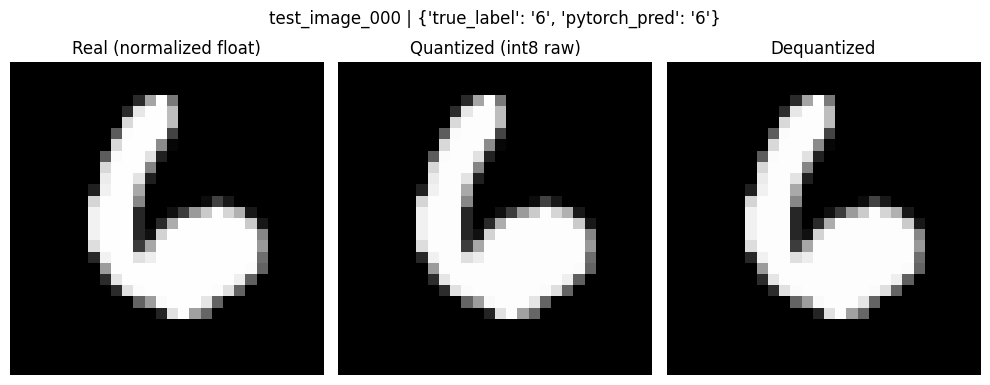

Max reconstruction error: 0.0126, Mean: 0.0099


In [35]:
import numpy as np
import matplotlib.pyplot as plt

def load_int8_hex(filename, shape=(28, 28)):
    values = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            v = int(line, 16)
            if v >= 128:
                v -= 256
            values.append(v)
    return np.array(values, dtype=np.int8).reshape(shape)

def load_float_txt(filename, shape=(28, 28)):
    values = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                values.append(float(line))
    return np.array(values, dtype=np.float32).reshape(shape)

def load_label_file(filename):
    info = {}
    with open(filename, "r") as f:
        for line in f:
            k, v = line.strip().split(":")
            info[k.strip()] = v.strip()
    return info

def visualize_triplet(base_name, scale, zero_point, shape=(28, 28)):
    int8_img   = load_int8_hex(f"{base_name}.txt", shape)
    real_img   = load_float_txt(f"{base_name}_real.txt", shape)
    label_info = load_label_file(f"{base_name}_label.txt")

    # Dequantize: real_value = (int8_value - zero_point) * scale
    dequant_img = (int8_img.astype(np.float32) - zero_point) * scale

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    axes[0].imshow(real_img, cmap="gray")
    axes[0].set_title("Real (normalized float)")
    axes[0].axis("off")

    axes[1].imshow(int8_img, cmap="gray")
    axes[1].set_title("Quantized (int8 raw)")
    axes[1].axis("off")

    axes[2].imshow(dequant_img, cmap="gray")
    axes[2].set_title("Dequantized")
    axes[2].axis("off")

    fig.suptitle(f"{base_name} | {label_info}")
    plt.tight_layout()
    plt.show()

    # Print a quick numeric sanity check
    err = np.abs(real_img - dequant_img)
    print(f"Max reconstruction error: {err.max():.4f}, Mean: {err.mean():.4f}")

# ---- Usage ----
visualize_triplet("test_image_000", scale=input_scale, zero_point=input_zp)

In [36]:
layer_params = {}
prev_scale, prev_zp = input_scale, input_zp

for layer in ["linear1", "linear2", "linear3"]:
    packed = state[f"{layer}._packed_params._packed_params"]
    weight = packed[0]
    bias   = packed[1]

    w_int8  = weight.int_repr().numpy().astype(np.int32)
    w_scale = weight.q_scale()

    layer_obj = getattr(net_quantized, layer)
    out_scale = layer_obj.scale
    out_zp    = layer_obj.zero_point

    bias_scale = prev_scale * w_scale
    bias_int32 = torch.round(bias / bias_scale).to(torch.int32).numpy()

    layer_params[layer] = dict(
        w=w_int8, w_scale=w_scale,
        b=bias_int32, b_scale=bias_scale,
        in_scale=prev_scale, in_zp=prev_zp,
        out_scale=out_scale, out_zp=out_zp,
    )
    prev_scale, prev_zp = out_scale, out_zp

for layer, p in layer_params.items():
    print(layer, "in_scale:", p["in_scale"], "w_scale:", p["w_scale"], "out_scale:", p["out_scale"])

linear1 in_scale: 0.025556690990924835 w_scale: 0.009987510740756989 out_scale: 1.1632198095321655
linear2 in_scale: 1.1632198095321655 w_scale: 0.0054409014992415905 out_scale: 0.7061786651611328
linear3 in_scale: 0.7061786651611328 w_scale: 0.005170081742107868 out_scale: 0.5272383689880371


In [37]:
def quant_linear(x_int8, in_zp, p, apply_relu):
    x = x_int8.astype(np.int32) - in_zp
    acc = x @ p["w"].T + p["b"]

    real_multiplier = (p["in_scale"] * p["w_scale"]) / p["out_scale"]   # float here only, for this validation pass
    out = np.round(acc * real_multiplier) + p["out_zp"]

    if apply_relu:
        out = np.maximum(out, p["out_zp"])
    return np.clip(out, -128, 127).astype(np.int8)

def manual_forward(x_float):
    x_int8 = torch.quantize_per_tensor(x_float, input_scale, input_zp, torch.quint8)
    x = x_int8.int_repr().numpy().astype(np.int8)

    x = quant_linear(x, input_zp, layer_params["linear1"], apply_relu=True)
    x = quant_linear(x, layer_params["linear1"]["out_zp"], layer_params["linear2"], apply_relu=True)
    x = quant_linear(x, layer_params["linear2"]["out_zp"], layer_params["linear3"], apply_relu=False)
    return x

correct, total = 0, 0
for images, labels in test_loader:
    x_flat = images.view(images.size(0), -1)
    logits_int8 = manual_forward(x_flat)
    preds = np.argmax(logits_int8, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)

print(f"Manual weight/bias-only accuracy: {correct/total:.3f}")

Manual weight/bias-only accuracy: 0.966


In [38]:
import math

def quantize_multiplier(real_multiplier):
    if real_multiplier == 0:
        return 0, 0
    q, exp = math.frexp(real_multiplier)
    q_fixed = int(round(q * (1 << 31)))
    if q_fixed == (1 << 31):
        q_fixed //= 2
        exp += 1
    shift = 31 - exp
    return q_fixed, shift

def multiply_by_quantized_multiplier(acc, m0, shift):
    acc = acc.astype(np.int64)
    product = acc * np.int64(m0)
    if shift > 0:
        rounding = np.int64(1) << (shift - 1)
        return (product + rounding) >> shift
    else:
        return product << (-shift)

In [39]:
for layer in ["linear1", "linear2", "linear3"]:
    p = layer_params[layer]
    real_mult = (p["in_scale"] * p["w_scale"]) / p["out_scale"]
    m0, shift = quantize_multiplier(real_mult)
    p["m0"], p["shift"] = m0, shift
    print(f"{layer}: real_multiplier={real_mult:.8f}  ->  M0={m0}, shift={shift}")

linear1: real_multiplier=0.00021943  ->  M0=1930144863, shift=43
linear2: real_multiplier=0.00896227  ->  M0=1231765115, shift=37
linear3: real_multiplier=0.00692476  ->  M0=1903464711, shift=38


In [40]:
def quant_linear_int_only(x_int8, in_zp, p, apply_relu):
    x = x_int8.astype(np.int32) - in_zp
    acc = x @ p["w"].T + p["b"]

    out = multiply_by_quantized_multiplier(acc, p["m0"], p["shift"]) + p["out_zp"]

    if apply_relu:
        out = np.maximum(out, p["out_zp"])
    return np.clip(out, -128, 127).astype(np.int8)

def manual_forward_int_only(x_float):
    x_int8 = torch.quantize_per_tensor(x_float, input_scale, input_zp, torch.quint8)
    x = x_int8.int_repr().numpy().astype(np.int8)

    x = quant_linear_int_only(x, input_zp, layer_params["linear1"], apply_relu=True)
    x = quant_linear_int_only(x, layer_params["linear1"]["out_zp"], layer_params["linear2"], apply_relu=True)
    x = quant_linear_int_only(x, layer_params["linear2"]["out_zp"], layer_params["linear3"], apply_relu=False)
    return x

correct, total = 0, 0
for images, labels in test_loader:
    x_flat = images.view(images.size(0), -1)
    logits_int8 = manual_forward_int_only(x_flat)
    preds = np.argmax(logits_int8, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)

print(f"Integer-only (M0/shift) accuracy: {correct/total:.3f}")

Integer-only (M0/shift) accuracy: 0.966


In [41]:
def split_weights_per_neuron(input_file, num_neurons, weights_per_neuron, layer_name):
    with open(input_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    assert len(lines) == num_neurons * weights_per_neuron, \
        f"عدد القيم {len(lines)} مش متوافق مع {num_neurons}×{weights_per_neuron}"

    for n in range(num_neurons):
        start = n * weights_per_neuron
        end = start + weights_per_neuron
        neuron_weights = lines[start:end]
        with open(f"{layer_name}_weights_n{n}.txt", "w") as f_out:
            f_out.write("\n".join(neuron_weights) + "\n")

# مثال للاستخدام على الطبقات التلاتة
split_weights_per_neuron("linear1_weights.txt", num_neurons=32, weights_per_neuron=784, layer_name="linear1")
split_weights_per_neuron("linear2_weights.txt", num_neurons=16, weights_per_neuron=32,  layer_name="linear2")
split_weights_per_neuron("linear3_weights.txt", num_neurons=10, weights_per_neuron=16,  layer_name="linear3")

In [ ]:
"""
golden_model.py

Reads the SAME weight/bias/image .txt files that feed the Verilog design,
and replicates neuron.v's exact integer datapath (MAC -> +bias -> M0/shift
rescale -> +zero_point -> ReLU -> clip) in pure Python.

Run this in the SAME folder as your linear{1,2,3}_weights_n*.txt,
linear{1,2,3}_bias_int32.txt (or per-neuron bias files), and test_image_XXX.txt.
"""

import os

# ---------------- EDIT THESE to match your current nn.v ----------------
IMAGE_FILE = "test_image_004.txt"     # must match the file DATA_MEMORY loads

LAYER_CFG = {
    "layer1": dict(n_in=784, n_out=32, IN_ZP=17, OUT_ZP=69,
                    M0=1930144863, SHIFT=43, APPLY_RELU=True),
    "layer2": dict(n_in=32,  n_out=16, IN_ZP=69, OUT_ZP=70,
                    M0=1231765115, SHIFT=37, APPLY_RELU=True),
    "layer3": dict(n_in=16,  n_out=10, IN_ZP=70, OUT_ZP=78,
                    M0=1903464711, SHIFT=38, APPLY_RELU=False),
}

# Per-layer bias values, IN THE SAME ORDER as neuron 0..N-1.
# Edit this block to match whatever is currently hardcoded in your nn.v
# "assign bias_data_neuron_layer_X[i] = ..." lines.
BIAS = {
    "layer1": [26, 73, -142, -83, -168, 159, 77, 128, -103, -260, 54, -182,
               -132, -40, -71, -140, 18, -71, -227, 27, -25, 86, 244, 23,
               -133, 433, 156, -93, 6, 10, -156, -253],
    "layer2": [-5, 0, -21, -5, 36, 10, 16, 49, -31, 22, -5, 11, -16, -8, 18, 50],
    "layer3": [-76, -25, 79, -14, 17, 9, 69, -49, 17, -51],
}


def read_hex_signed8(path):
    """Read a file of 2-hex-digit lines, interpreted as SIGNED int8
       (matches how Verilog reads them into a `signed [7:0]` register)."""
    vals = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            v = int(line, 16)
            if v >= 128:
                v -= 256
            vals.append(v)
    return vals


def multiply_by_quantized_multiplier(acc, m0, shift):
    """Exact integer replica of neuron.v's rescale stage:
       (((acc) * M0) + (1 << (shift-1))) >>> shift"""
    product = acc * m0
    rounding = 1 << (shift - 1)
    return (product + rounding) >> shift   # Python >> is arithmetic for negative ints


def run_layer(name, cfg, inputs, weight_file_pattern):
    n_in, n_out = cfg["n_in"], cfg["n_out"]
    outputs = []
    for n in range(n_out):
        w = read_hex_signed8(weight_file_pattern.format(n=n))
        assert len(w) == n_in, f"{name} neuron {n}: expected {n_in} weights, got {len(w)}"

        acc = 0
        for k in range(n_in):
            acc += (inputs[k] - cfg["IN_ZP"]) * w[k]

        acc += BIAS[name][n]
        rescaled = multiply_by_quantized_multiplier(acc, cfg["M0"], cfg["SHIFT"])
        with_zp = rescaled + cfg["OUT_ZP"]

        if cfg["APPLY_RELU"] and with_zp < cfg["OUT_ZP"]:
            with_zp = cfg["OUT_ZP"]

        clipped = max(-128, min(127, with_zp))
        outputs.append(clipped)
    return outputs


def main():
    for i in range(20):
        if i < 10:
            image_path = f"test_image_00{i}.txt"
        elif i < 100:
            image_path = f"test_image_0{i}.txt"
        else:
            image_path = f"test_image_{i}.txt"
        pixels = read_hex_signed8(image_path)
        assert len(pixels) == 784, f"expected 784 pixels, got {len(pixels)}"

        l1_out = run_layer("layer1", LAYER_CFG["layer1"], pixels, "linear1_weights_n{n}.txt")
        # print("Layer1 outputs:", l1_out)

        l2_out = run_layer("layer2", LAYER_CFG["layer2"], l1_out, "linear2_weights_n{n}.txt")
        # print("Layer2 outputs:", l2_out)

        l3_out = run_layer("layer3", LAYER_CFG["layer3"], l2_out, "linear3_weights_n{n}.txt")
        # print("Layer3 outputs (final 10 logits, pre-argmax):", l3_out)

        predicted_digit = l3_out.index(max(l3_out))
        print("Predicted digit (argmax):", predicted_digit)


if __name__ == "__main__":
    main()

Layer1 outputs: [72, 69, 69, 70, 69, 86, 69, 85, 85, 69, 79, 69, 69, 69, 85, 69, 82, 69, 69, 73, 69, 69, 83, 83, 69, 74, 69, 79, 69, 69, 69, 69]
Layer2 outputs: [70, 84, 81, 70, 72, 70, 92, 77, 83, 92, 70, 70, 85, 89, 70, 70]
Layer3 outputs (final 10 logits, pre-argmax): [71, 72, 63, 56, 88, 70, 104, 48, 61, 56]
Predicted digit (argmax): 6
Layer1 outputs: [71, 69, 69, 69, 72, 84, 69, 69, 86, 69, 69, 69, 69, 70, 77, 69, 81, 75, 73, 69, 69, 69, 72, 84, 70, 69, 69, 70, 69, 69, 69, 69]
Layer2 outputs: [70, 72, 77, 70, 86, 70, 85, 84, 74, 91, 70, 70, 78, 94, 71, 70]
Layer3 outputs (final 10 logits, pre-argmax): [70, 64, 76, 66, 72, 74, 101, 57, 74, 53]
Predicted digit (argmax): 6
Layer1 outputs: [81, 72, 89, 73, 81, 70, 69, 69, 69, 74, 79, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 82, 78, 69, 69, 88, 80, 69, 69]
Layer2 outputs: [71, 70, 91, 70, 70, 103, 70, 74, 70, 76, 82, 80, 70, 75, 77, 85]
Layer3 outputs (final 10 logits, pre-argmax): [68, 72, 80, 71, 52, 66, 40, 93, 70, 63]
Pr